In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('bbc_news_dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB


In [4]:
X = df['Text']
y = df['Category']

In [5]:
category_names = df['Category'].unique()
print(category_names)

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str


In [ ]:
value_counts = df['Category'].value_counts()
print(value_counts)

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


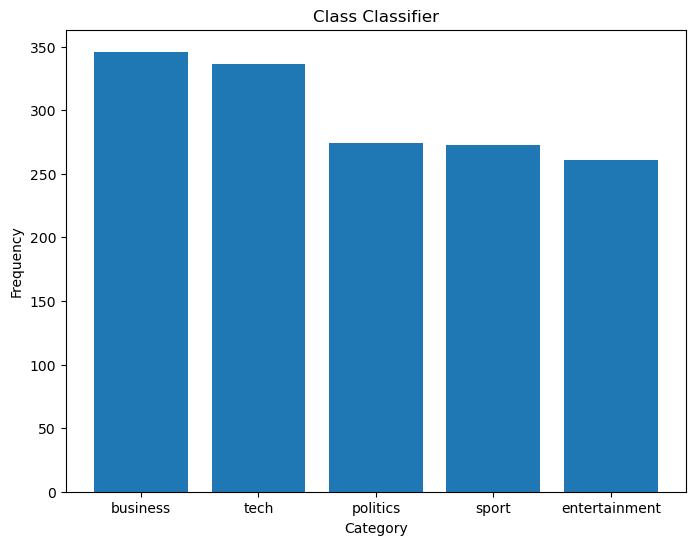

In [9]:
plt.figure(figsize=(8,6))
plt.bar(x=category_names, height=value_counts)
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Class Classifier")
plt.show()

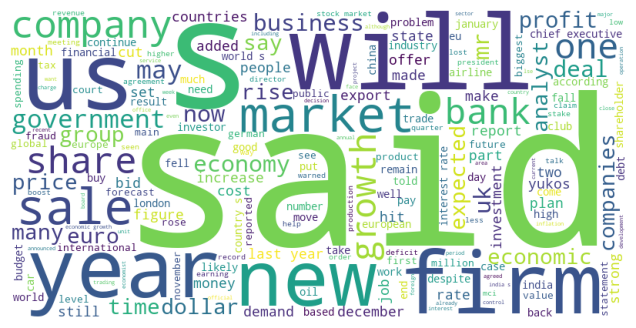

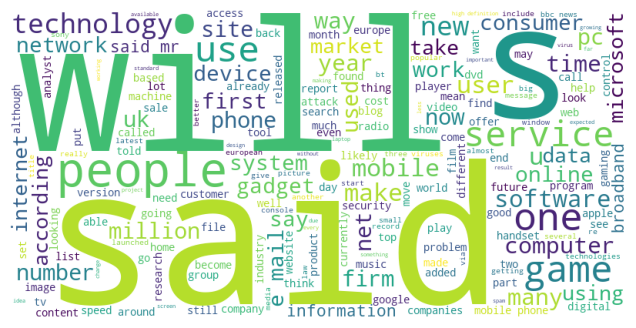

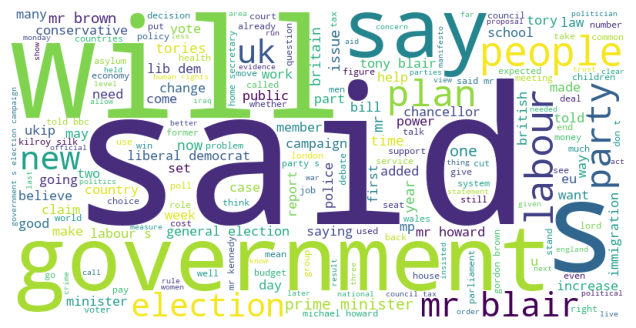

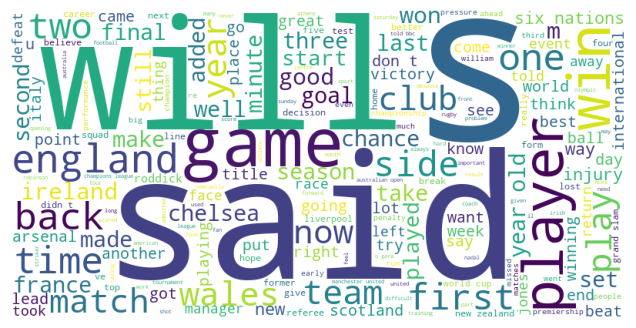

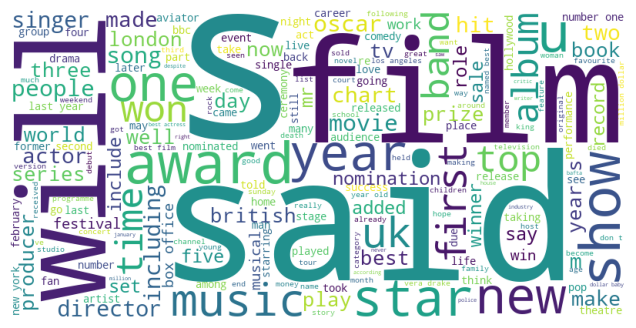

In [ ]:
# Generate Word Clouds
from wordcloud import WordCloud
for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,
                   background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Build Model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [13]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



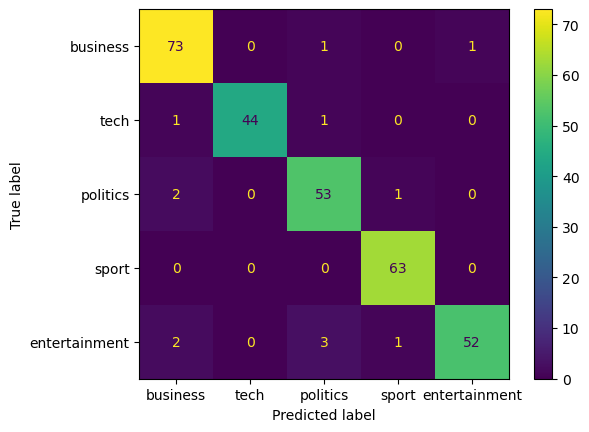

In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=category_names).plot()

In [15]:
# Test with New Articles
texts = ['Enter any news article text here.']
prediction = model.predict(texts)
print(prediction)

['tech']


In [16]:
# Save Model
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS


In [19]:
sample_text = [""" World Cup winners in 1998 and 2018, France have created another special team and are favourites to win the 2026 competition.

They showed just why they remain the team to beat this year with an impressive 2-0 victory over Morocco on Thursday to become the first nation into the semi-finals.

France have also won the European Championship twice, but has Didier Deschamps, in his final tournament as manager, created the best ever Les Bleus team?

If they lift the trophy on 19 July, they can justify that claim, with former midfielder Patrick Vieira, who played in the 3-0 final win over Brazil in 1998, saying this current crop were on the verge of greatness.

Speaking on ITV Sport, Vieira said: "We're talking about a generation of players and when you look at the squad and the attacking players, it is maybe one of the best, because you have so many players - it is so unbelievable."

Image gallerySkip image gallery
"""]
prediction = model.predict(sample_text)
print(prediction)

['sport']


In [20]:
sample_text = ["""At least 12 people have died and 19 others are missing in a wildfire in southern Spain, Andalusia's regional leader Juanma Moreno has said.

Another local official said early indications suggested four of the victims are British.

Hundreds of people are trying to contain the fire, which is thought to have been caused by a downed power line and spread to a wooded area around Los Gallardos, Almería.

A sustained heatwave with temperatures of around 40C (104F) has caused wildfires across southern Europe this summer.

Hundreds of firefighters are battling major incidents in France, Portugal and Spain, with thousands forced to leave their homes.

The bodies of the 11 victims were found in and around the small village of Bédar, just outside Los Gallardos.

Antonio Sanz, Andalusia's health and emergencies minister, said the fire had been complex and rapid and the majority or even all of the victims may have been foreign nationals. The regional government had given an earlier death toll of 12, although Sanz said the number was provisional.

Four people were found trapped in their car, said Sanz, while other victims were found elsewhere, apparently trying to escape the flames. He said the four in the car were believed to be "of British origin" and that the car had a steering wheel on the right."""]
prediction = model.predict(sample_text)
print(prediction)

['politics']


In [21]:
sample_text = ["""For 17 years, mysterious radio signals baffled astronomers in Australia. Some blamed solar flares. The public suspected aliens. Eventually, they learned the culprit was closer to home: their telescope was picking up bursts of energy from the office microwave at lunchtime.

Telescopes aren't the only technology that's vulnerably to pesky microwaves. They can also mess up your wi-fi.

Wi-fi, like most wireless communications technology, transmits information over radio waves. Governments reserve most radio frequencies for specific purposes, like law enforcement, air traffic control and AM and FM radio stations. But some are free for unlicensed public use.

"""]
prediction = model.predict(sample_text)
print(prediction)

['tech']
